In [1]:

import pandas as pd
import numpy as np
from PIL import Image, ImageOps
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import seaborn as sns
from torch import Tensor
from torch.nn import Linear
from torch.nn import ReLU
from torch.nn import Softmax
from torch.nn import Module
from torch.nn import Flatten
from torch.nn import AdaptiveAvgPool2d
from torch.optim import SGD, Adam
from torch.nn import CrossEntropyLoss
from torch.nn.init import kaiming_uniform_
from torch.nn.init import xavier_uniform_
    
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision.transforms import Compose
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import torch
import os
import re
import json

In [2]:
SEED = 0
import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Ensure deterministic behavior where possible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [3]:
#Constants

#path para guardar o dataset
PATH = './'
DATA_FOLDER = './data_images/MIQR-CC-Dataset/processed'
TEST_FOLDER = './dataset/test'
LABELS_PATH = './labels.json'
VAL_FOLDER = './dataset/val'

BATCH_SIZE = 128

In [4]:
#device management 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

device = get_default_device()
print(device)

cuda


In [5]:
def augment_with_inversions(files, labels, inverts):
    aug_files   = files   + files
    aug_labels  = list(labels) + [1 - l for l in labels]
    aug_inverts = list(inverts) + [not iv for iv in inverts]
    return aug_files, np.array(aug_labels, dtype=np.int64), np.array(aug_inverts, dtype=bool)

class FolderDataset(Dataset):
    def __init__(self, data_folder, test_folder, val_folder, labels_path, img_size=128):

        # --- extract the image<n> keys from the test folder to exclude ---
        test_keys = set()
        for root, dirs, files in os.walk(test_folder):
            for fname in files:
                if not fname.lower().endswith('.png'):
                    continue
                match = re.search(r'(?:^|_)(image\d+)(?:_|\.|$)', fname, re.IGNORECASE)
                if match:
                    test_keys.add(match.group(1).lower())
                    
        for root, dirs, files in os.walk(val_folder):
            for fname in files:
                if not fname.lower().endswith('.png'):
                    continue
                match = re.search(r'(?:^|_)(image\d+)(?:_|\.|$)', fname, re.IGNORECASE)
                if match:
                    test_keys.add(match.group(1).lower())

        # --- load labels.json ---
        with open(labels_path, 'r') as f:
            labels_raw = json.load(f)
        # normalize keys: strip path separators, lowercase
        labels_map = {os.path.basename(k): v for k, v in labels_raw}

        # --- collect label-1 and label-0 images, excluding test keys ---
        label1_files, label0_files = [], []
        label1_patients, label0_patients = [], []

        for fname in os.listdir(data_folder):
            if not fname.lower().endswith('.png'):
                continue

            # exclude test images
            match = re.search(r'(?:^|_)(image\d+)(?:_|\.|$)', fname, re.IGNORECASE)
            if match and match.group(1).lower() in test_keys:
                continue

            if fname not in labels_map:
                continue

            label = labels_map[fname]
            patient_id = fname.split('_image')[0]
            full_path = os.path.join(data_folder, fname)

            if label == 1:
                label1_files.append(full_path)
                label1_patients.append(patient_id)
            else:
                label0_files.append(full_path)
                label0_patients.append(patient_id)

        # --- subsample label-0 to 5x label-1 count ---
        n1 = len(label1_files)
        n0_target = 9 * n1

        label0_files = np.array(label0_files)
        label0_patients = np.array(label0_patients)

        if len(label0_files) > n0_target:
            idx = np.random.choice(len(label0_files), n0_target, replace=False)
        else:
            idx = np.arange(len(label0_files))
        label0_files = label0_files[idx]
        label0_patients = label0_patients[idx]

        # --- mark 4/9 of label-0 images as inverted (label flipped to 1) ---
        n0 = len(label0_files)
        n_invert = int(round(4 / 9 * n0))
        invert_flags = np.zeros(n0, dtype=bool)
        invert_idx = np.random.choice(n0, n_invert, replace=False)
        invert_flags[invert_idx] = True

        # --- combine all files, patients, labels, invert flags ---
        all_files = (
            list(label1_files) +
            list(label0_files)
        )
        all_patients = (
            list(label1_patients) +
            list(label0_patients)
        )
        all_labels = (
            [1] * n1 +
            [1 if invert_flags[i] else 0 for i in range(n0)]
        )
        all_invert = (
            [False] * n1 +
            list(invert_flags)
        )

        all_files, all_labels, all_invert = augment_with_inversions(all_files, all_labels, all_invert)
        all_patients = all_patients + all_patients  # duplicate patients to match
        all_patients = np.array(all_patients, dtype='<U')
        
        self.img_size = img_size

        # --- compute normalization range ---
        xmin, xmax = float('inf'), float('-inf')
        for path, invert in zip(all_files, all_invert):
            arr = self._load_raw(path, invert)
            xmin = min(xmin, arr.min())
            xmax = max(xmax, arr.max())
        self.xmin = xmin
        self.denominator = max(1.0, xmax - xmin)

        all_patients = np.array(all_patients, dtype='<U')
        all_labels   = np.array(all_labels,   dtype=np.int64)
        all_invert   = np.array(all_invert,   dtype=bool)

        # --- train / test split by patient (80/20) ---
        patient_ids = np.unique(all_patients)
        np.random.shuffle(patient_ids)
        n_train_patients = max(1, int(0.8 * len(patient_ids)))
        train_patients = set(patient_ids[:n_train_patients])

        train_mask = np.array([p in train_patients for p in all_patients])

        self.train_files  = [f for f, k in zip(all_files,   train_mask) if k]
        self.train_labels = all_labels[train_mask]
        self.train_invert = all_invert[train_mask]

        self.test_files   = [f for f, k in zip(all_files,   train_mask) if not k]
        self.test_labels  = all_labels[~train_mask]
        self.test_invert  = all_invert[~train_mask]

    def _load_raw(self, path, invert):
        """Open PNG, center-crop 372x372, resize to img_size, return float32 array."""
        img = Image.open(path).convert('L')
        w, h = img.size                        # expected 512x512
        crop = 350
        left   = (w - crop) // 2
        top    = (h - crop) // 2
        img    = img.crop((left, top, left + crop, top + crop))
        img    = img.resize((self.img_size, self.img_size), Image.LANCZOS)
        if invert:
            img = ImageOps.invert(img)
        return np.array(img, dtype=np.float32)

    def _load_tensor(self, path, invert):
        arr = self._load_raw(path, invert)
        arr = (arr - self.xmin) / self.denominator
        return torch.from_numpy(arr[np.newaxis, :, :])   # (1, H, W)

    # --- legacy item/len helpers (mirrors original API) ---
    def __len_train__(self):  return len(self.train_files)
    def __len_test__(self):   return len(self.test_files)

    def __getitem_train__(self, idx):
        return [self._load_tensor(self.train_files[idx], self.train_invert[idx]),
                self.train_labels[idx]]

    def __getitem_test__(self, idx):
        return [self._load_tensor(self.test_files[idx], self.test_invert[idx]),
                self.test_labels[idx]]

    def get_splits(self):
        def build_tensors(files, labels, inverts):
            xs = torch.stack([self._load_tensor(f, iv) for f, iv in zip(files, inverts)])
            ys = torch.from_numpy(labels.astype(np.int64))
            return torch.utils.data.TensorDataset(xs, ys)

        train = build_tensors(self.train_files, self.train_labels, self.train_invert)
        test  = build_tensors(self.test_files,  self.test_labels,  self.test_invert)
        return train, test


def prepare_data_flat(data_folder, test_folder, val_folder, labels_path):
    dataset = FolderDataset(data_folder, test_folder, val_folder, labels_path)
    train, test = dataset.get_splits()

    train_dl     = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True)
    test_dl      = DataLoader(test,  batch_size=BATCH_SIZE, shuffle=True)
    train_dl_all = DataLoader(train, batch_size=len(train), shuffle=False)
    test_dl_all  = DataLoader(test,  batch_size=len(test),  shuffle=False)
    return train_dl, test_dl, train_dl_all, test_dl_all


train_dl, test_dl, train_dl_all, test_dl_all = prepare_data_flat(
    DATA_FOLDER, TEST_FOLDER, VAL_FOLDER, LABELS_PATH
)

In [6]:
from IPython.display import display

def visualize_dataset(train_dl, test_dl):
    print(f"Quantidade de casos de Treino: {len(train_dl.dataset)}")
    print(f"Quantidade de casos de Teste: {len(test_dl.dataset)}")
    x, y = next(iter(train_dl))
    print(f"Shape tensor batch casos treino, input: {x.shape}, output: {y.shape}")
    x, y = next(iter(test_dl))
    print(f"Shape tensor batch casos test, input: {x.shape}, output: {y.shape}")
    print(y)

visualize_dataset(train_dl, test_dl)

Quantidade de casos de Treino: 5352
Quantidade de casos de Teste: 1308
Shape tensor batch casos treino, input: torch.Size([128, 1, 128, 128]), output: torch.Size([128])
Shape tensor batch casos test, input: torch.Size([128, 1, 128, 128]), output: torch.Size([128])
tensor([1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
        1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
        1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
        1, 0, 1, 0, 0, 0, 0, 0])


torch.Size([128, 1, 128, 128])


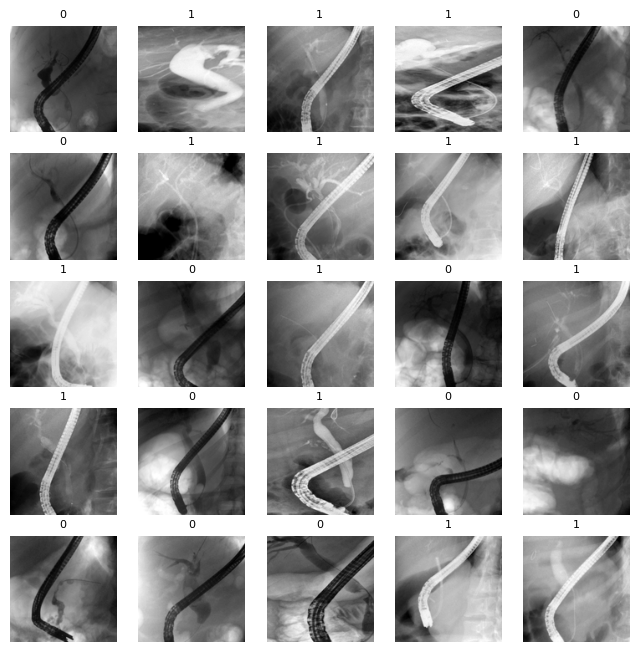

In [7]:
def visualize_images(dl):
    i, (inputs, targets) = next(enumerate(dl))
    print(inputs.shape)
    plt.figure(figsize=(8, 8))
    for i in range(min(25, len(inputs))):
        plt.subplot(5, 5, i + 1)
        plt.axis('off')
        plt.title(int(targets[i]), fontsize=8)
        plt.imshow(inputs[i][0], cmap='gray')
    plt.show()

visualize_images(train_dl)

-----casos_treino------
casos: 5352
['0', '1']
[2676 2676]
5352


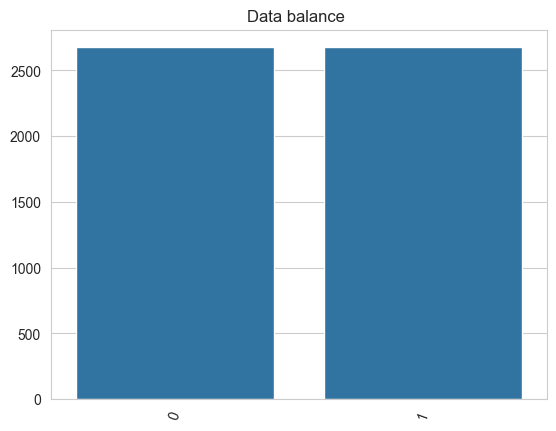

-----casos_teste------
casos: 1308
['0', '1']
[654 654]
1308


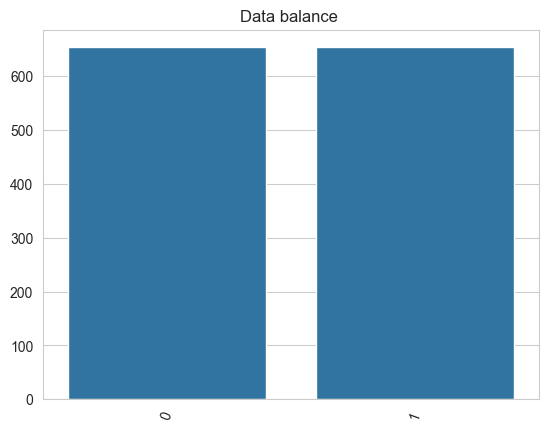

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
def visualize_holdout_balance(dl):
    _, labels = next(iter(dl))                            
    sns.set_style('whitegrid')
    print("casos:",len(labels))
    x, y = np.unique(labels, return_counts=True)
    x=[str(n) for n in x]
    print(x)
    print(y)
    print(np.sum(y))
    grafico=sns.barplot(x=x,y=y)
    grafico.set_title('Data balance ')
    plt.xticks(rotation=70)
    plt.show() 

print("-----casos_treino------")   
visualize_holdout_balance(train_dl_all)
print("-----casos_teste------") 
visualize_holdout_balance(test_dl_all)

In [9]:
class MLP(Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.pool = AdaptiveAvgPool2d((8, 8))  # 1*8*8 = 64 features
        self.flatten = Flatten()
        self.hidden1 = Linear(64, 32)
        kaiming_uniform_(self.hidden1.weight, nonlinearity='relu')
        self.act1 = ReLU()
        self.hidden2 = Linear(32, 2)
        xavier_uniform_(self.hidden2.weight)
        self.act2 = Softmax(dim=1)

    def forward(self, X):
        X = self.pool(X)
        X = self.flatten(X)
        X = self.hidden1(X)
        X = self.act1(X)
        X = self.hidden2(X)
        X = self.act2(X)
        return X

model = MLP()

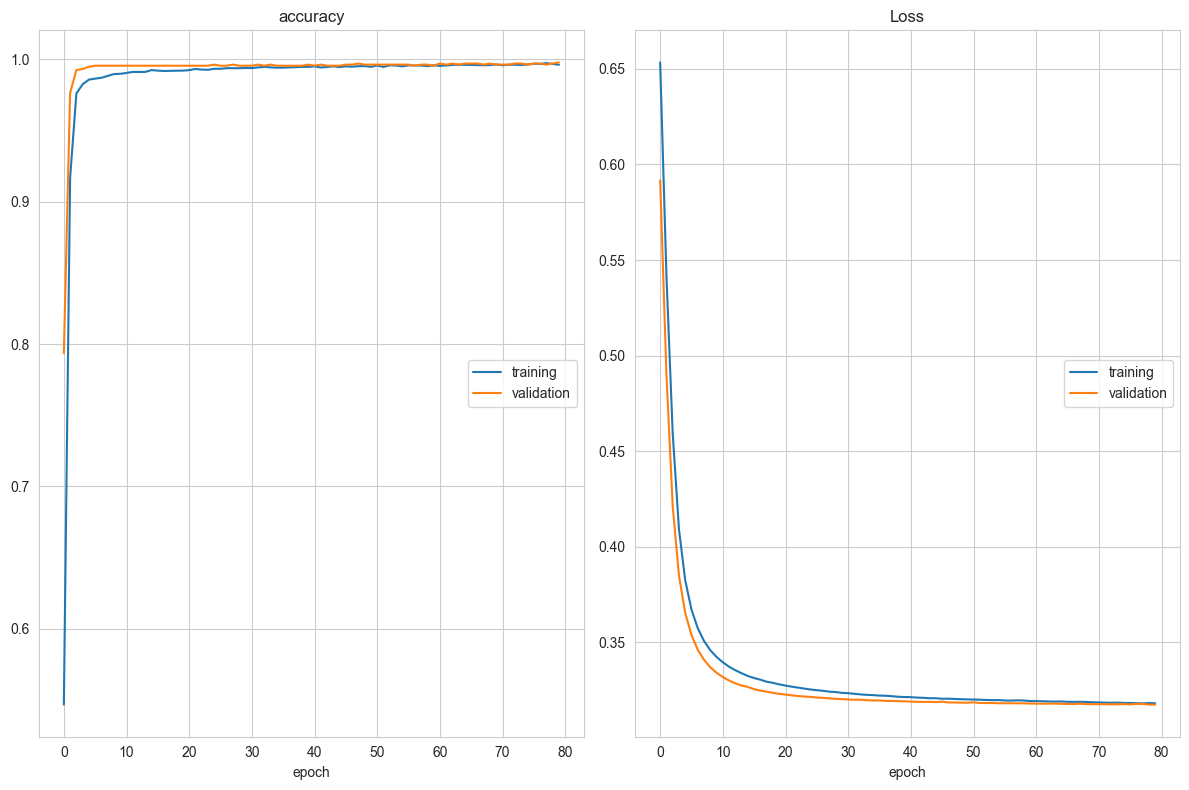

accuracy
	training         	 (min:    0.547, max:    0.997, cur:    0.996)
	validation       	 (min:    0.794, max:    0.998, cur:    0.998)
Loss
	training         	 (min:    0.318, max:    0.653, cur:    0.318)
	validation       	 (min:    0.318, max:    0.592, cur:    0.318)


In [10]:
from livelossplot import PlotLosses
EPOCHS = 80
LEARNING_RATE = 0.0005

def train_model(train_dl, test_dl, model):
    liveloss = PlotLosses()
    criterion = CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
    for epoch in range(EPOCHS):
        logs = {}
        epoch_loss = 0
        epoch_acc  = 0

        model.train()
        for i, (inputs, labels) in enumerate(train_dl):
            labels = labels.long()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            acc = accuracy_score(labels.numpy(), np.argmax(outputs.detach().numpy(), axis=1))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            epoch_acc  += acc

        val_loss = 0
        val_acc  = 0
        model.eval()
        with torch.no_grad():
            for i, (inputs, labels) in enumerate(test_dl):
                labels = labels.long()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                acc = accuracy_score(labels.numpy(), np.argmax(outputs.detach().numpy(), axis=1))
                val_loss += loss.item()
                val_acc  += acc

        print(f'Epoch {epoch:03}: | Loss: {epoch_loss/len(train_dl):.5f} | Acc: {epoch_acc/len(train_dl):.3f} | Val Loss: {val_loss/len(test_dl):.5f} | Val Acc: {val_acc/len(test_dl):.3f}')
        logs['loss']     = epoch_loss / len(train_dl)
        logs['accuracy'] = epoch_acc  / len(train_dl)
        logs['val_loss']     = val_loss / len(test_dl)
        logs['val_accuracy'] = val_acc  / len(test_dl)
        liveloss.update(logs)
        liveloss.send()

train_model(train_dl, test_dl_all, model)

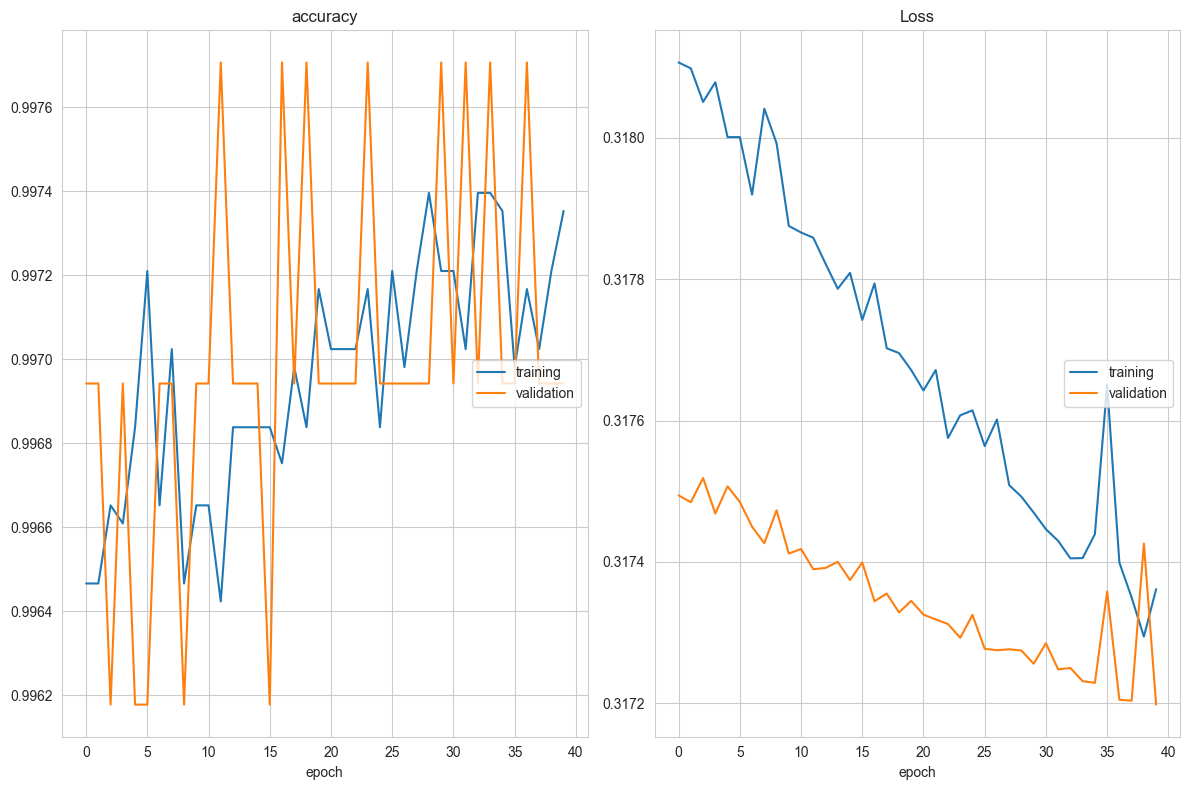

accuracy
	training         	 (min:    0.996, max:    0.997, cur:    0.997)
	validation       	 (min:    0.996, max:    0.998, cur:    0.997)
Loss
	training         	 (min:    0.317, max:    0.318, cur:    0.317)
	validation       	 (min:    0.317, max:    0.318, cur:    0.317)


In [11]:

EPOCHS = 40
LEARNING_RATE = 0.0002

train_model(train_dl, test_dl_all, model)

Accuracy: 0.997

acertou:1304 falhou:4
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       654
           1       1.00      1.00      1.00       654

    accuracy                           1.00      1308
   macro avg       1.00      1.00      1.00      1308
weighted avg       1.00      1.00      1.00      1308

[[651   3]
 [  1 653]]


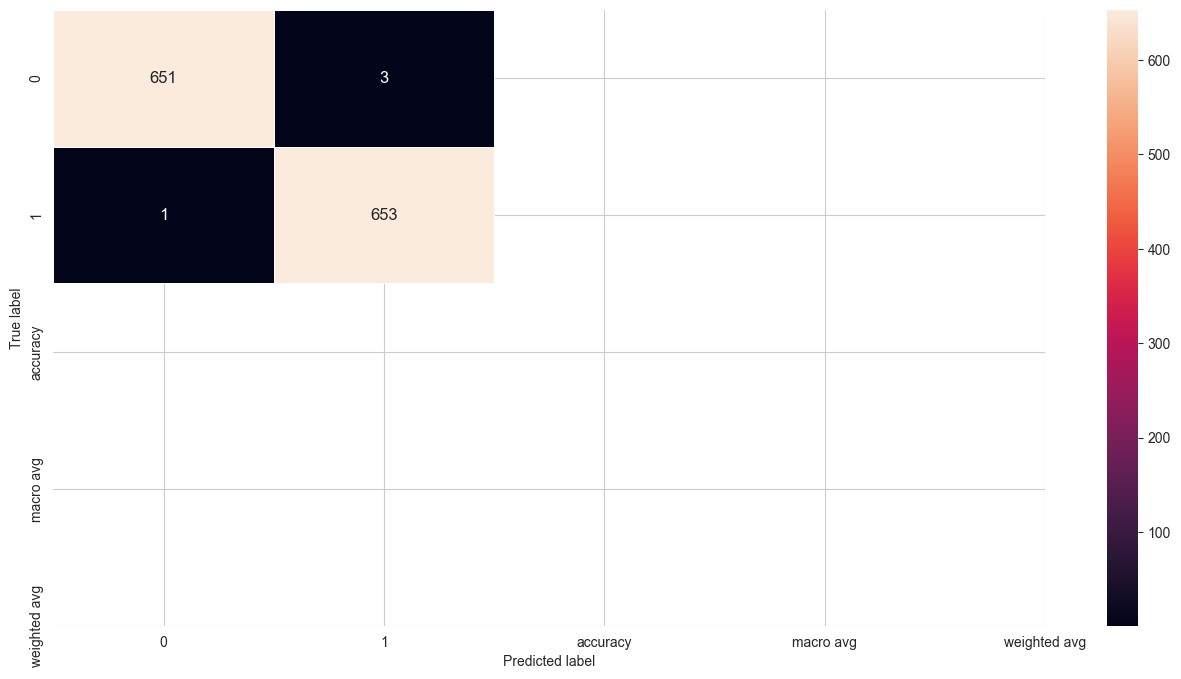


Imagens erradas: 4


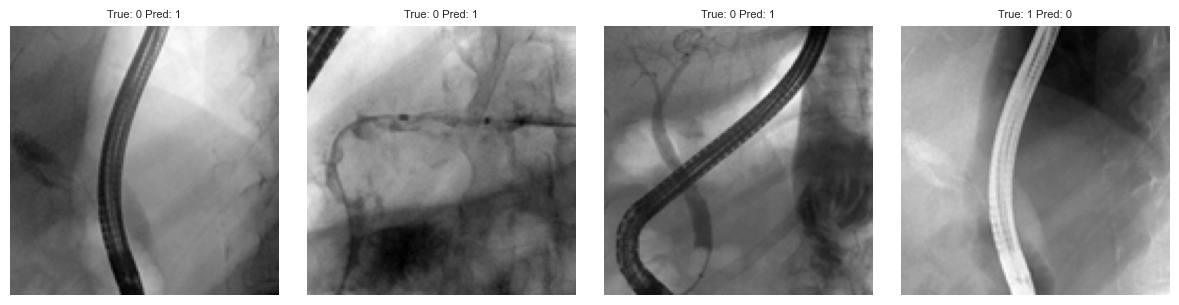

In [16]:
def evaluate_model(test_dl, model):
    predictions = list()
    actual_values = list()
    wrong_images = list()
    for i, (inputs, labels) in enumerate(test_dl):
        outputs = model(inputs)
        yprev = outputs.detach().numpy()
        actual = labels.numpy()
        yprev = np.argmax(yprev, axis=1)
        for j in range(len(actual)):
            if yprev[j] != actual[j]:
                wrong_images.append((inputs[j], actual[j], yprev[j]))
        actual = actual.reshape((len(actual), 1))
        yprev = yprev.reshape((len(yprev), 1))
        predictions.append(yprev)
        actual_values.append(actual)
    predictions, actual_values = np.vstack(predictions), np.vstack(actual_values)
    return actual_values, predictions, wrong_images

def display_wrong_images(wrong_images):
    n = len(wrong_images)
    cols = 5
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, (img, actual, pred) in enumerate(wrong_images):
        plt.subplot(rows, cols, i + 1)
        plt.axis('off')
        plt.title(f'True: {actual} Pred: {pred}', fontsize=8)
        plt.imshow(img[0], cmap='gray')
    plt.tight_layout()
    plt.show()

def display_confusion_matrix(cm, list_classes):
    plt.figure(figsize=(16, 8))
    sns.heatmap(cm, annot=True, xticklabels=list_classes, yticklabels=list_classes, annot_kws={"size": 12}, fmt='g', linewidths=.5)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

actual_values, predictions, wrong_images = evaluate_model(test_dl_all, model)

acertou = 0
falhou  = 0
for r, p in zip(actual_values, predictions):
    if r == p: acertou += 1
    else: falhou += 1

acc = accuracy_score(actual_values, predictions)
print(f'Accuracy: {acc:0.3f}\n')
print(f'acertou:{acertou} falhou:{falhou}')

print(classification_report(actual_values, predictions))
cr = classification_report(actual_values, predictions, output_dict=True)
list_classes = list(cr.keys())[0:10]
cm = confusion_matrix(actual_values, predictions)

print(cm)
display_confusion_matrix(cm, list_classes)

print(f'\nImagens erradas: {len(wrong_images)}')
display_wrong_images(wrong_images)

Accuracy: 0.997

acertou:5337 falhou:15
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2676
           1       1.00      1.00      1.00      2676

    accuracy                           1.00      5352
   macro avg       1.00      1.00      1.00      5352
weighted avg       1.00      1.00      1.00      5352

[[2667    9]
 [   6 2670]]


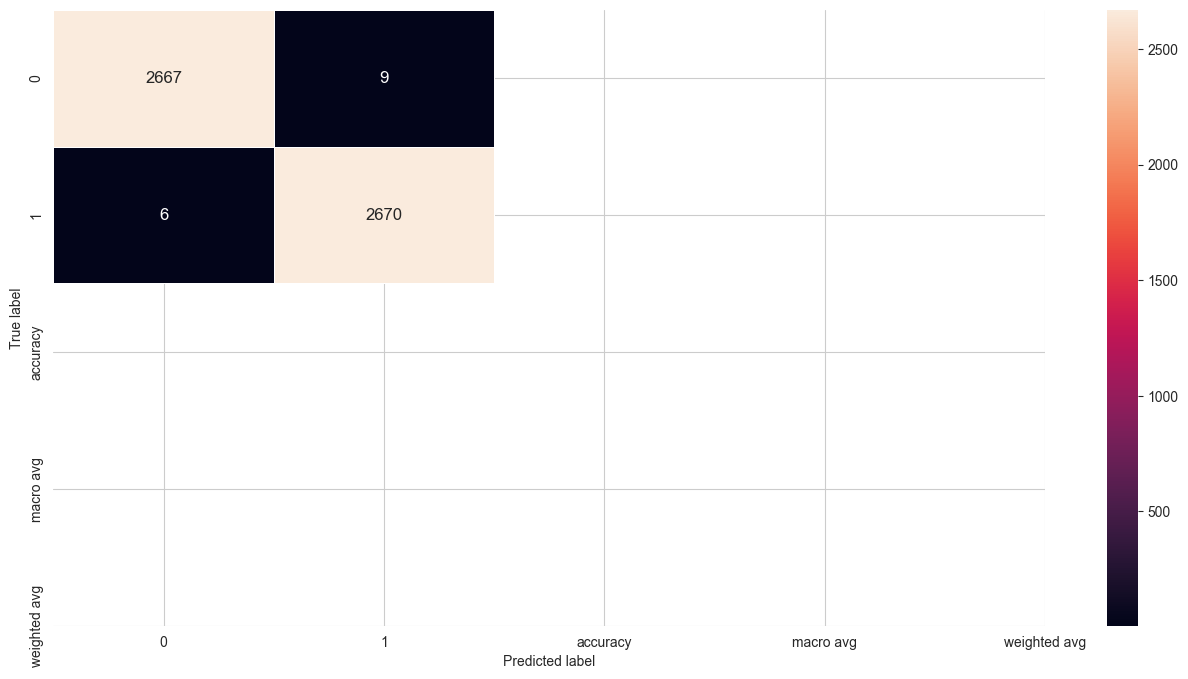


Imagens erradas: 15


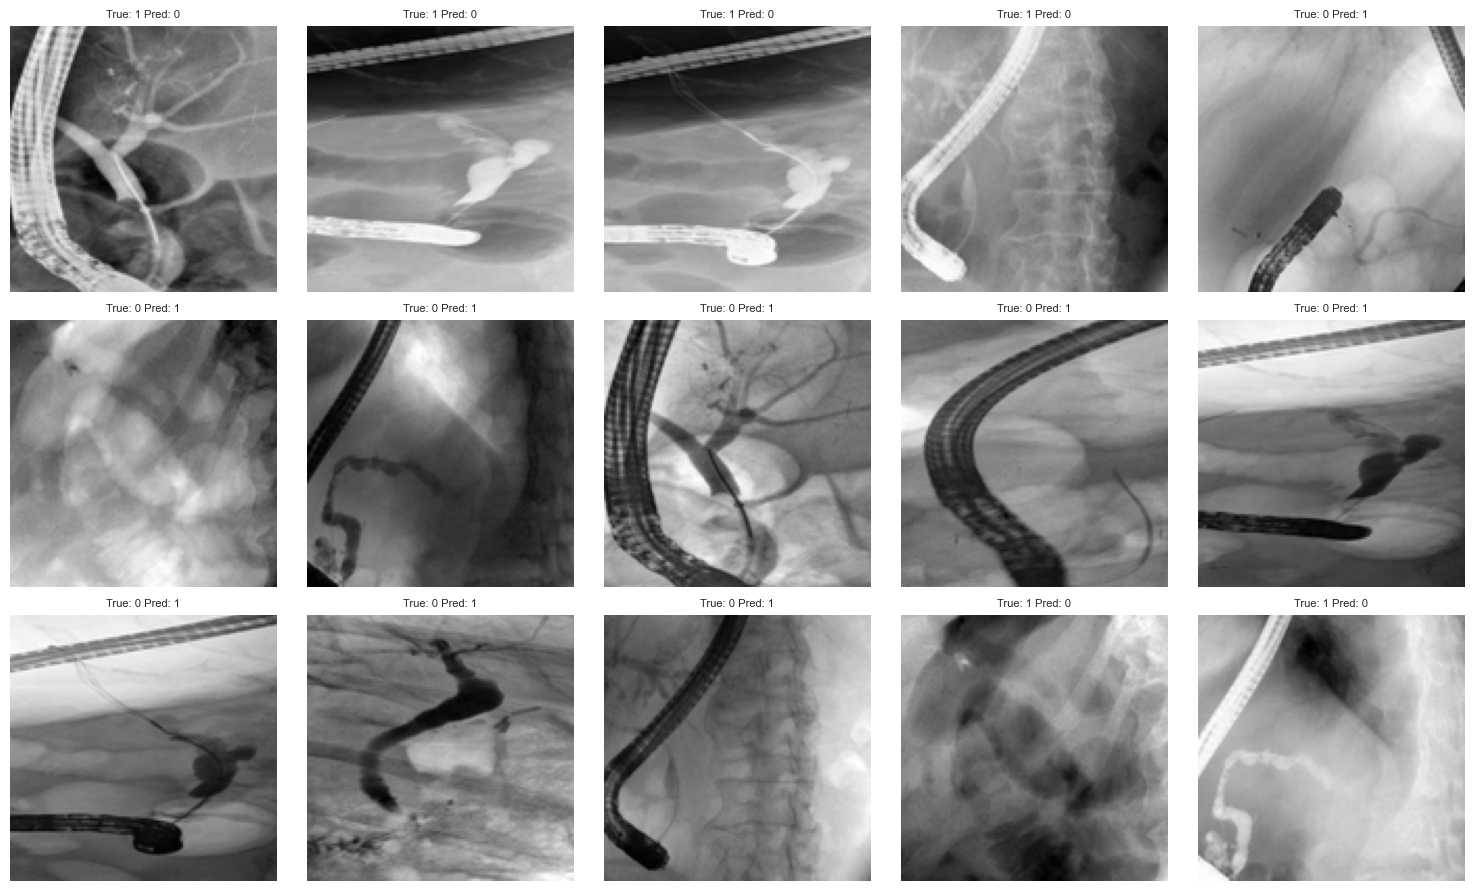

In [17]:
actual_values, predictions, wrong_images = evaluate_model(train_dl_all, model)

acertou = 0
falhou  = 0
for r, p in zip(actual_values, predictions):
    if r == p: acertou += 1
    else: falhou += 1

acc = accuracy_score(actual_values, predictions)
print(f'Accuracy: {acc:0.3f}\n')
print(f'acertou:{acertou} falhou:{falhou}')

print(classification_report(actual_values, predictions))
cr = classification_report(actual_values, predictions, output_dict=True)
list_classes = list(cr.keys())[0:10]
cm = confusion_matrix(actual_values, predictions)

print(cm)
display_confusion_matrix(cm, list_classes)

print(f'\nImagens erradas: {len(wrong_images)}')
display_wrong_images(wrong_images)

In [18]:
def preprocess_image(path, img_size=64, invert=False):
    """
    Mirrors _load_raw: center-crop 350x350 → resize to img_size → tensor.
    """
    img = Image.open(path).convert('L')
    w, h = img.size                        # expected 512x512
    crop = 350
    left = (w - crop) // 2
    top  = (h - crop) // 2
    img  = img.crop((left, top, left + crop, top + crop))
    img  = img.resize((img_size, img_size), Image.LANCZOS)
    if invert:
        img = ImageOps.invert(img)
    arr = np.array(img, dtype=np.float32) / 255.0   # normalise to [0,1]
    # model expects (N, C, H, W) — add batch + channel dims
    tensor = torch.tensor(arr).unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)
    return tensor


def get_label1_images(folder, model, img_size=64, invert=False,
                      extensions=('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
    """
    Walk *folder* (including subfolders), run inference on every image,
    and return the paths of images predicted as label 1.

    Args:
        folder     : str or Path – root folder (TEST_FOLDER or VAL_FOLDER)
        model      : trained MLP (or any model with the same interface)
        img_size   : spatial size used during training (default 64)
        invert     : whether to invert pixel values (match your dataset flag)
        extensions : image file extensions to consider

    Returns:
        list[Path]  – paths predicted as label 1, sorted
    """
    folder = Path(folder)
    model.eval()

    label1_paths = []

    image_paths = sorted([
        p for p in folder.rglob('*')
        if p.suffix.lower() in extensions
    ])

    print(f"Found {len(image_paths)} images under '{folder}'")

    with torch.no_grad():
        for path in image_paths:
            try:
                tensor = preprocess_image(path, img_size=img_size, invert=invert)
                output = model(tensor)                          # (1, 2) softmax probs
                pred   = int(torch.argmax(output, dim=1).item())
                if pred == 1:
                    label1_paths.append(path)
            except Exception as e:
                print(f"  [skip] {path.name}: {e}")

    print(f"Label-1 predictions: {len(label1_paths)} / {len(image_paths)}")
    return label1_paths

In [19]:
test_label1 = get_label1_images(TEST_FOLDER, model)
val_label1  = get_label1_images(VAL_FOLDER,  model)

# Print results
for p in test_label1:
    print(p)
    
for p in val_label1:
    print(p)

Found 267 images under 'dataset\test'
Label-1 predictions: 6 / 267
Found 234 images under 'dataset\val'
Label-1 predictions: 3 / 234
dataset\test\Lithiasis\1504_1504_image18855_section_1.png
dataset\test\Normal\1498_1498_image18848_section_1.png
dataset\test\Normal\1498_1498_image18848_section_2.png
dataset\test\Normal\1517_1517_image18872_section_1.png
dataset\test\Normal\1517_1517_image18872_section_2.png
dataset\test\Normal\1517_1517_image18872_section_3.png
dataset\val\Lithiasis\1505_1505_image18857_section_1.png
dataset\val\Lithiasis\1505_1505_image18857_section_2.png
dataset\val\Lithiasis\665_665_image7657.png


In [ ]:
torch.save(model.state_dict(), "inverter.pth")